> ***Action Plan:*** 

> **Yahan pe hum numerical columns ke upar apne Random Sample Imputer ko lagane wale hain.** 
 
> *******************Titanic dataset me utne suitable categorical columns nahi hain, isliye categorical data ke liye hum aage ek alag se notebook bana kar practice karenge.*******************

---

In [1]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('Titanic_data_Set.csv',usecols=['Age','Fare','Survived'])

In [3]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [4]:
df.isnull().mean() * 100

Survived     0.00000
Age         19.86532
Fare         0.00000
dtype: float64

In [5]:
df['Age'].value_counts()

Age
24.00    30
22.00    27
18.00    26
28.00    25
30.00    25
         ..
24.50     1
0.67      1
0.42      1
34.50     1
74.00     1
Name: count, Length: 88, dtype: int64

In [6]:
df['Age'].value_counts().max()

np.int64(30)

***But Yaha pe Mujhe Koi Bhi ek random Value Chhaiye***

In [7]:
X = df.drop(columns=['Survived'])
y = df['Survived']

In [8]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [9]:
X_train

,Age,Fare
30,40.0,27.7208
10,4.0,16.7000
873,47.0,9.0000
182,9.0,31.3875
876,20.0,9.8458
...,...,...
534,30.0,8.6625
584,NaN,8.7125
493,71.0,49.5042
527,NaN,221.7792


In [10]:
X_train['Age_imputed'] = X_train['Age']
X_test['Age_imputed'] = X_test['Age']

In [11]:
X_test.tail()

,Age,Fare,Age_imputed
89,24.0,8.0500,24.0
80,22.0,9.0000,22.0
846,NaN,69.5500,NaN
870,26.0,7.8958,26.0
251,29.0,10.4625,29.0


In [12]:
X_train['Age_imputed'][X_train['Age_imputed'].isnull()] = X_train['Age'].dropna().sample(X_train['Age'].isnull().sum()).values
X_test['Age_imputed'][X_test['Age_imputed'].isnull()] = X_train['Age'].dropna().sample(X_test['Age'].isnull().sum()).values

In [13]:
X_train['Age'].dropna().sample(X_train['Age'].isnull().sum()).values

array([34.  , 15.  , 36.  , 18.  , 48.  , 59.  , 22.  , 43.  , 31.  ,
       28.  , 21.  , 39.  , 40.  , 30.  , 32.  , 34.  , 32.  , 58.  ,
       29.  , 32.  , 34.  , 18.  , 32.  , 31.  , 47.  , 32.  , 28.  ,
       37.  , 14.  , 52.  , 33.  , 31.  , 40.  , 38.  , 29.  , 40.  ,
       40.  ,  9.  , 45.  , 21.  ,  1.  , 32.  , 16.  , 24.  , 32.  ,
       57.  , 30.  , 29.  , 51.  , 17.  , 31.  , 58.  , 26.  , 43.  ,
       38.  , 25.  , 34.  , 20.  , 24.  , 17.  , 32.5 , 16.  ,  8.  ,
       27.  ,  9.  , 34.  , 61.  , 18.  , 27.  , 24.  , 29.  , 62.  ,
       16.  , 19.  , 52.  , 36.  , 49.  , 26.  , 45.  , 30.  , 23.  ,
       50.  , 24.  , 14.  , 41.  , 17.  , 26.  , 24.  , 14.  , 60.  ,
        0.75,  3.  , 19.  , 29.  , 26.  , 35.  , 65.  , 49.  , 40.  ,
       24.  , 45.  ,  2.  , 31.  , 64.  , 28.  , 13.  , 25.  , 48.  ,
       38.  , 19.  , 48.  , 19.  , 16.  , 33.  ,  4.  , 11.  , 26.  ,
       41.  ,  9.  , 20.  , 14.5 , 56.  , 32.  , 18.  , 21.  , 29.  ,
       47.  , 61.  ,

⬆️ ***Ye Hamre 148 Random Values a gai Hai***

In [14]:
X_train['Age'].isnull().sum()

np.int64(148)

In [15]:
X_train

,Age,Fare,Age_imputed
30,40.0,27.7208,40.0
10,4.0,16.7000,4.0
873,47.0,9.0000,47.0
182,9.0,31.3875,9.0
876,20.0,9.8458,20.0
...,...,...,...
534,30.0,8.6625,30.0
584,NaN,8.7125,23.0
493,71.0,49.5042,71.0
527,NaN,221.7792,35.0


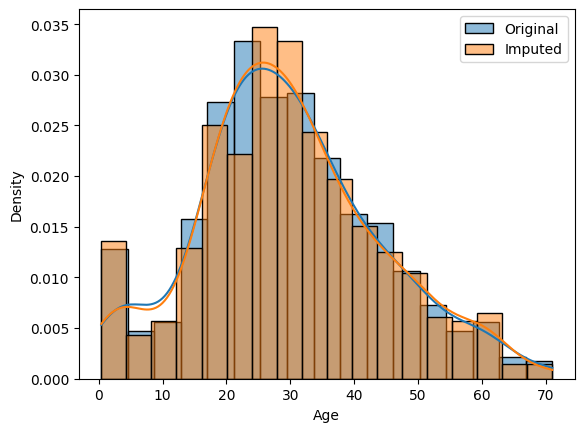

In [16]:
sns.histplot(X_train['Age'],label='Original', kde=True, stat='density')
sns.histplot(X_train['Age_imputed'],label = 'Imputed', kde=True, stat='density')
plt.legend()
plt.show()



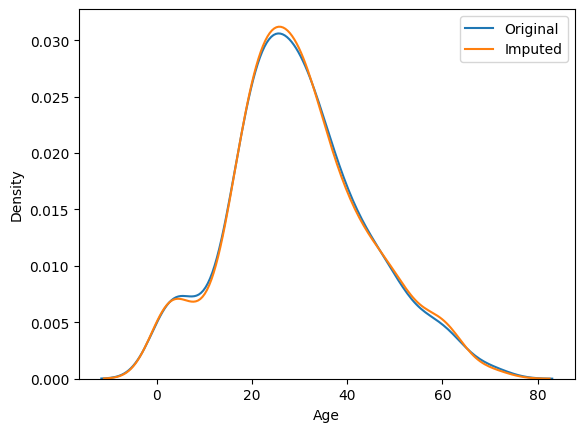

In [17]:
#Haan bhai, agar tumhe sirf KDE curve chahiye, to histplot() ki jagah directly sns.kdeplot() use karo.
sns.kdeplot(X_train['Age'], label='Original')
sns.kdeplot(X_train['Age_imputed'], label='Imputed')
plt.legend()
plt.show()

In [18]:
print('Original variable variance: ', X_train['Age'].var())
print('Variance after random imputation: ', X_train['Age_imputed'].var())

Original variable variance:  204.34951339046142
Variance after random imputation:  204.1639783561687


In [19]:
X_train[['Fare', 'Age', 'Age_imputed']].cov()

,Fare,Age,Age_imputed
Fare,2368.246832,71.512440,57.714490
Age,71.512440,204.349513,204.349513
Age_imputed,57.714490,204.349513,204.163978


<Axes: >

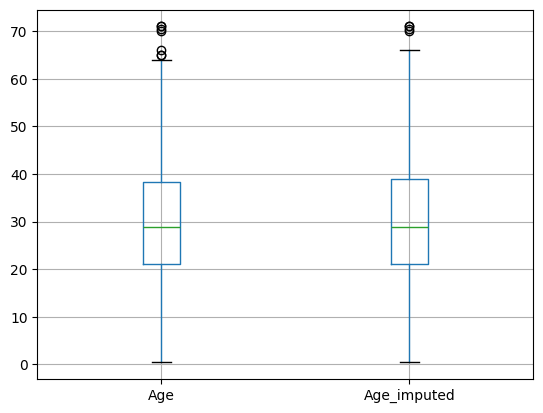

In [20]:
X_train[['Age', 'Age_imputed']].boxplot()

In [21]:
# sampled_value = X_train['Age'].dropna().sample(1, random_state=int(observation['Fare']))
# sampled_value = X_train['Age'].dropna().sample(1).values[0]

### ***Yaha Se Haam Ab Houseing Wala Data Use karne wale hai***

***Import Data***

In [22]:
data = pd.read_csv('house-train.csv',usecols=['GarageQual','FireplaceQu', 'SalePrice'])

In [23]:
data.head()

,FireplaceQu,GarageQual,SalePrice
0,NaN,TA,208500
1,TA,TA,181500
2,TA,TA,223500
3,Gd,TA,140000
4,TA,TA,250000


***Step 1 — data***
*data tumhara Pandas DataFrame hai.*

***Step 2 — data.isnull()***
*Ye har cell ko check karta hai:*
* Null hai → True
* Null nahi hai → False

***Step 3 — .mean()***
*Yahan tumhari thinking sahi direction mein ha*
***Pandas mein:***
* True  = 1
* False = 0

To Age ke liye:

* False
* True
* False
* False

becomes:

* 0
* 1
* 0
* 0

Mean:

* (0 + 1 + 0 + 0) / 4
* = 1/4
* = 0.25
* Matlab 0.25 = 25%

***Step 4 — * 100 kyun?***

*Yahi tumhara main doubt hai. 👇*
*.mean() hume proportion/fraction deta ha*


#### ***So:***
`data.isnull().mean() * 100`

***ka meaning hai:***

`Har column mein kitne percent values missing (NaN) hain.`


In [24]:
data.isnull().mean()*100

FireplaceQu    47.260274
GarageQual      5.547945
SalePrice       0.000000
dtype: float64

In [25]:
X = data
y = data['SalePrice']

In [26]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [27]:
X_train['GarageQual_imputed'] = X_train['GarageQual']
X_test['GarageQual_imputed'] = X_test['GarageQual']

X_train['FireplaceQu_imputed'] = X_train['FireplaceQu']
X_test['FireplaceQu_imputed'] = X_test['FireplaceQu']

In [28]:
X_train.sample(5)

,FireplaceQu,GarageQual,SalePrice,GarageQual_imputed,FireplaceQu_imputed
513,NaN,TA,134000,TA,NaN
509,NaN,TA,124500,TA,NaN
683,TA,TA,285000,TA,TA
677,NaN,Fa,109500,Fa,NaN
1379,NaN,TA,167500,TA,NaN


In [29]:
X_train['GarageQual_imputed'][X_train['GarageQual_imputed'].isnull()] = X_train['GarageQual'].dropna().sample(X_train['GarageQual'].isnull().sum()).values
X_test['GarageQual_imputed'][X_test['GarageQual_imputed'].isnull()] = X_train['GarageQual'].dropna().sample(X_test['GarageQual'].isnull().sum()).values

X_train['FireplaceQu_imputed'][X_train['FireplaceQu_imputed'].isnull()] = X_train['FireplaceQu'].dropna().sample(X_train['FireplaceQu'].isnull().sum()).values
X_test['FireplaceQu_imputed'][X_test['FireplaceQu_imputed'].isnull()] = X_train['FireplaceQu'].dropna().sample(X_test['FireplaceQu'].isnull().sum()).values

C:\Users\acer\AppData\Local\Temp\ipykernel_27840\856878696.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train['GarageQual_imputed'][X_train['GarageQual_imputed'].isnull()] = X_train['GarageQual'].dropna().sample(X_train['GarageQual'].isnull().sum()).values
C:\Users\acer\AppData\Local\Temp\ipykernel_27840\856878696.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_test['GarageQual_imputed'][X_test['GarageQual_imputed'].isnull()] = X_train['GarageQual'].dropna().sample(X_test['GarageQual'].isnull().sum()).values
C:\Users\acer\AppData\Local\Temp\ipykernel_27840\856878696.py:4: SettingWithCopyWarning: 
A value

####  ⬆️ ***Tumhare 4 lines ka modern version***

#### ⬇️ ***Yaha pe hai***

In [30]:
X_train.loc[X_train['GarageQual_imputed'].isnull(), 'GarageQual_imputed'] = X_train['GarageQual'].dropna().sample(X_train['GarageQual_imputed'].isnull().sum()).values

X_test.loc[X_test['GarageQual_imputed'].isnull(), 'GarageQual_imputed'] = X_train['GarageQual'].dropna().sample(X_test['GarageQual_imputed'].isnull().sum()).values

X_train.loc[X_train['FireplaceQu_imputed'].isnull(), 'FireplaceQu_imputed'] = X_train['FireplaceQu'].dropna().sample(X_train['FireplaceQu_imputed'].isnull().sum()).values

X_test.loc[X_test['FireplaceQu_imputed'].isnull(), 'FireplaceQu_imputed'] = X_train['FireplaceQu'].dropna().sample(X_test['FireplaceQu_imputed'].isnull().sum()).values

In [31]:
temp = pd.concat(
        [
            X_train['GarageQual'].value_counts() / len(X_train['GarageQual'].dropna()),
            X_train['GarageQual_imputed'].value_counts() / len(X_train)
        ],
        axis=1)

temp.columns = ['original', 'imputed']

In [32]:
temp

,original,imputed
TA,0.951043,0.951199
Fa,0.037171,0.037671
Gd,0.009973,0.009418
Po,0.000907,0.000856
Ex,0.000907,0.000856


In [33]:
temp = pd.concat(
        [
            X_train['FireplaceQu'].value_counts() / len(X_train['FireplaceQu'].dropna()),
            X_train['FireplaceQu_imputed'].value_counts() / len(df)
        ],
        axis=1)

temp.columns = ['original', 'imputed']

temp

,original,imputed
Gd,0.494272,0.652076
TA,0.412439,0.537598
Fa,0.040917,0.053872
Po,0.027823,0.034792
Ex,0.024550,0.032548


C:\Users\acer\AppData\Local\Temp\ipykernel_27840\1827688635.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train[X_train['FireplaceQu'] == category]['SalePrice'],hist=False,label=category)
C:\Users\acer\AppData\Local\Temp\ipykernel_27840\1827688635.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6

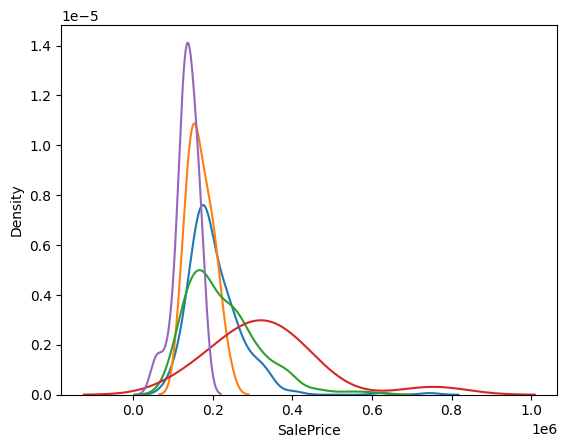

In [34]:
for category in X_train['FireplaceQu'].dropna().unique():
    sns.distplot(X_train[X_train['FireplaceQu'] == category]['SalePrice'],hist=False,label=category)
plt.show()

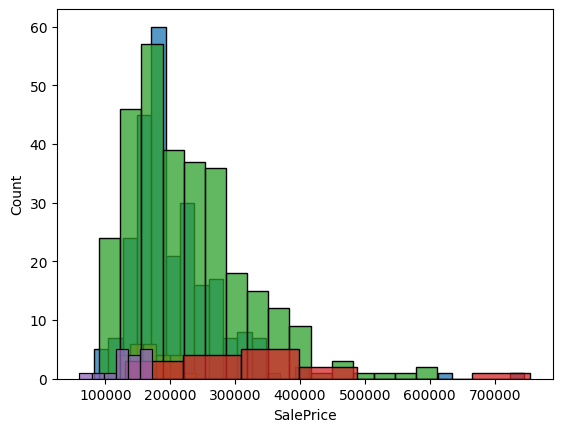

In [35]:
for category in X_train['FireplaceQu'].dropna().unique():
    sns.histplot(X_train[X_train['FireplaceQu'] == category]['SalePrice'],label=category)
plt.show()

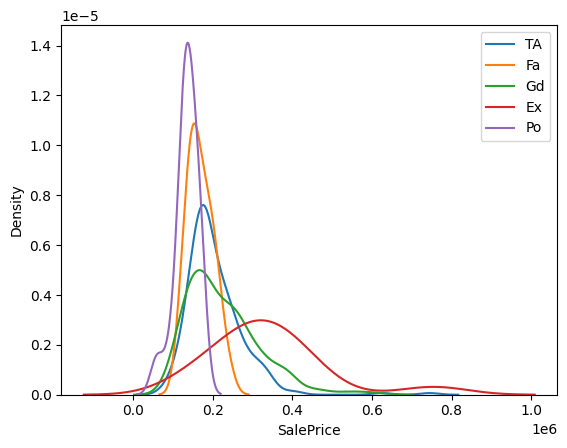

In [36]:
for category in X_train['FireplaceQu'].dropna().unique():
    sns.kdeplot(X_train[X_train['FireplaceQu'] == category]['SalePrice'],label=category)
plt.legend()
plt.show()

C:\Users\acer\AppData\Local\Temp\ipykernel_27840\722808554.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train[X_train['FireplaceQu_imputed'] == category]['SalePrice'],hist=False,label=category)
C:\Users\acer\AppData\Local\Temp\ipykernel_27840\722808554.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974

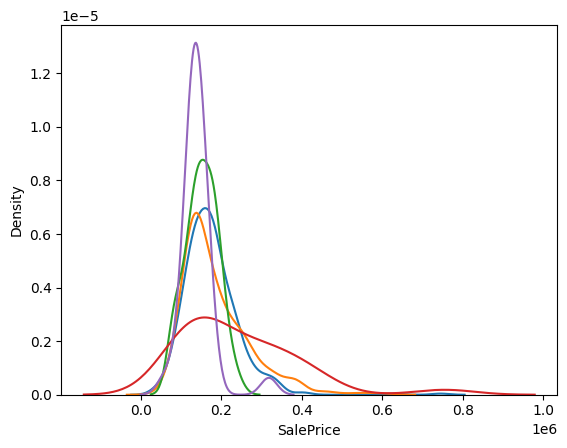

In [37]:
for category in X_train['FireplaceQu_imputed'].dropna().unique():
    sns.distplot(X_train[X_train['FireplaceQu_imputed'] == category]['SalePrice'],hist=False,label=category)
plt.show()

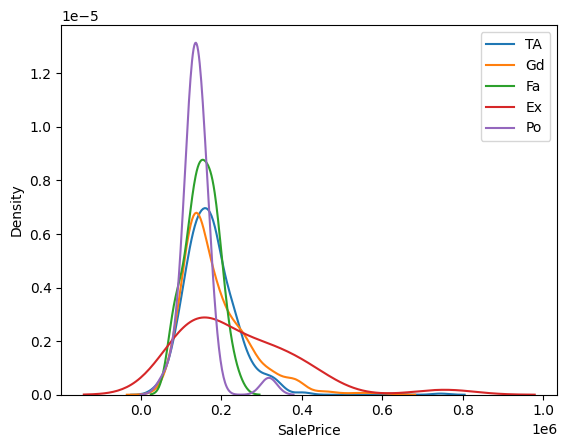

In [38]:
for category in X_train['FireplaceQu_imputed'].dropna().unique():
    sns.kdeplot(X_train[X_train['FireplaceQu_imputed'] == category]['SalePrice'],label=category)
plt.legend()
plt.show()

____























***Cheat Sheet***

<div style="background-color:#ffffff;padding:24px;border-radius:14px;font-family:-apple-system,BlinkMacSystemFont,'Segoe UI',Roboto,sans-serif;color:#ffffff;border:5px solid #fbf8f8;width:100%;line-height:1.2;"> <div style="text-align:center;padding-bottom:16px;border-bottom:1px solid #fff9f9;margin-bottom:22px;"> <span style="background-color:#0c2d3d;color:#38bdf8;border:1px solid #0284c7;font-size:20px;font-weight:700;padding:3px 10px;border-radius:12px;text-transform:uppercase;">Pandas Cheat Sheet</span> <h2 style="color:#008080;margin:8px 0 4px 0;font-size:22px;">DataFrame vs Series &amp; Core Column Operations</h2> <div style="color:#f96161;font-size:18.5px;">Mastering df['col'], unique(), sum(), unique().sum(), and value_counts()</div> </div> <table style="width:100%;border-collapse:separate;border-spacing:10px 0px;margin-bottom:16px;"> <tr> <td style="width:50%;background-color:#141414;border:1px solid #131313;border-top:3px solid #c084fc;border-radius:10px;padding:14px;vertical-align:top;"> <div style="font-size:14px;font-weight:bold;color:#ffffff;margin-bottom:4px;">1. What is <code style="background-color:#000000;color:#38bdf8;padding:1px 5px;border-radius:4px;">df</code>?</div> <div style="font-size:12px;color:#dddddd;">Represents the <b style="color:#ffffff;">complete 2D table</b> (rows &amp; columns together).</div> <div style="background-color:#000000;border:1px solid #262626;border-radius:6px;padding:6px;margin-top:8px;font-family:monospace;font-size:11.5px;color:#c084fc;">df &rarr; DataFrame (2D Table)</div> </td> <td style="width:50%;background-color:#141414;border:1px solid #333333;border-top:3px solid #38bdf8;border-radius:10px;padding:14px;vertical-align:top;"> <div style="font-size:14px;font-weight:bold;color:#ffffff;margin-bottom:4px;">2. What is <code style="background-color:#000000;color:#38bdf8;padding:1px 5px;border-radius:4px;">df['Age']</code>?</div> <div style="font-size:12px;color:#dddddd;">Selecting a single column creates a <b style="color:#ffffff;">Pandas Series</b>.</div> <div style="background-color:#000000;border:1px solid #262626;border-radius:6px;padding:6px;margin-top:8px;font-family:monospace;font-size:11.5px;color:#38bdf8;">df['Age'] &rarr; Series (1D Column)</div> </td> </tr> </table> <div style="background-color:#141414;border:1px solid #333333;border-left:4px solid #38bdf8;border-radius:8px;padding:14px;margin-bottom:12px;"> <div style="font-size:14px;font-weight:bold;color:#38bdf8;margin-bottom:4px;">df['Age'].unique() &nbsp;<span style="font-size:11px;color:#aaaaaa;font-weight:normal;">("Kaun-kaun si distinct values hain?")</span></div> <div style="font-size:12px;color:#dddddd;">Duplicates filter karke sirf distinct values ka <b style="color:#ffffff;">NumPy Array</b> deta hai. Strictly Series operation hai — DataFrame par direct nahi chalta.</div> <div style="background-color:#000000;padding:8px 10px;border-radius:6px;margin-top:6px;font-family:monospace;font-size:11.5px;color:#38bdf8;">Data: [20, 21, 20, 22, 21, 20] &rarr; Output: array([20, 21, 22])</div> </div> <div style="background-color:#1b1230;border:1.5px solid #818cf8;border-radius:10px;padding:14px;margin-bottom:14px;"> <div style="font-size:13px;font-weight:800;color:#a78bfa;margin-bottom:4px;">🔗 unique().sum() &nbsp;<span style="font-size:11px;color:#aaaaaa;font-weight:normal;">("Unique values ka total?")</span></div> <div style="font-size:12px;color:#dddddd;margin-bottom:6px;">Pehle duplicates hatate hain, phir sirf bachi hui unique values ko add karte hain.</div> <div style="background-color:#000000;padding:10px;border-radius:6px;font-family:monospace;font-size:11.5px;color:#fbbf24;text-align:center;"> 20, 21, 20, 22, 21, 20 &nbsp;&rarr;&nbsp; .unique() &nbsp;&rarr;&nbsp; [20, 21, 22] &nbsp;&rarr;&nbsp; .sum() &nbsp;&rarr;&nbsp; <b style="color:#fbbf24;">63</b> </div> </div> <div style="background-color:#141414;border:1px solid #333333;border-left:4px solid #c084fc;border-radius:8px;padding:14px;margin-bottom:14px;"> <div style="font-size:14px;font-weight:bold;color:#c084fc;margin-bottom:4px;">df['Age'].value_counts() &nbsp;<span style="font-size:11px;color:#aaaaaa;font-weight:normal;">("Har value kitni baar aayi hai?")</span></div> <div style="font-size:12px;color:#dddddd;">Har unique element ki <b style="color:#ffffff;">frequency / count</b> nikal kar deta hai (Series output).</div> <div style="background-color:#000000;padding:8px 10px;border-radius:6px;margin-top:6px;font-family:monospace;font-size:11.5px;color:#c084fc;">Output &rarr; 20: 3, &nbsp;21: 2, &nbsp;22: 1</div> </div> <div style="background-color:#1b1230;border:1.5px solid #818cf8;border-radius:10px;padding:14px;margin-bottom:14px;"> <div style="font-size:13px;font-weight:800;color:#a78bfa;margin-bottom:8px;">⚠️ CRITICAL DIFFERENCE: sum() vs unique().sum()</div> <table style="width:100%;border-collapse:separate;border-spacing:8px 0px;"> <tr> <td style="width:50%;background-color:#000000;padding:12px;border-radius:6px;border:1px solid #3730a3;vertical-align:top;"> <div style="color:#34d399;font-weight:bold;font-size:12px;margin-bottom:4px;">df['Age'].sum() &nbsp;(Normal Sum)</div> <div style="font-size:11.5px;color:#dddddd;">Column ki saari rows ko seedha add karta hai (Duplicates included).</div> <div style="font-family:monospace;font-size:11px;color:#34d399;margin-top:6px;">20+21+20+22+21+20 = <b>124</b></div> </td> <td style="width:50%;background-color:#000000;padding:12px;border-radius:6px;border:1px solid #3730a3;vertical-align:top;"> <div style="color:#fbbf24;font-weight:bold;font-size:12px;margin-bottom:4px;">df['Age'].unique().sum() &nbsp;(Unique Sum)</div> <div style="font-size:11.5px;color:#dddddd;">Pehle duplicates filter karta hai, fir bachi unique values ka sum karta hai.</div> <div style="font-family:monospace;font-size:11px;color:#fbbf24;margin-top:6px;">20+21+22 = <b>63</b></div> </td> </tr> </table> </div> <div style="background-color:#141414;border:1px solid #262626;border-radius:8px;padding:12px;margin-bottom:14px;"> <div style="font-size:13px;font-weight:bold;color:#ffffff;margin-bottom:6px;">📊 DataFrame vs Series Support</div> <table style="width:100%;font-size:12px;color:#dddddd;border-collapse:collapse;"> <tr style="background-color:#000000;border-bottom:1px solid #333333;text-align:left;"> <th style="padding:8px 10px;color:#aaaaaa;">Method</th> <th style="padding:8px 10px;color:#aaaaaa;">DataFrame (df)</th> <th style="padding:8px 10px;color:#aaaaaa;">Series (df['Age'])</th> <th style="padding:8px 10px;color:#aaaaaa;">Execution Rule</th> </tr> <tr style="border-bottom:1px solid #262626;"> <td style="padding:8px 10px;font-weight:bold;color:#ffffff;">.unique()</td> <td style="padding:8px 10px;color:#f87171;font-weight:bold;">❌ Not directly</td> <td style="padding:8px 10px;color:#34d399;font-weight:bold;">✅ Yes</td> <td style="padding:8px 10px;font-size:11px;color:#aaaaaa;">1D column vector method hai.</td> </tr> <tr style="border-bottom:1px solid #262626;"> <td style="padding:8px 10px;font-weight:bold;color:#ffffff;">.value_counts()</td> <td style="padding:8px 10px;color:#f87171;font-weight:bold;">❌ Not directly</td> <td style="padding:8px 10px;color:#34d399;font-weight:bold;">✅ Yes</td> <td style="padding:8px 10px;font-size:11px;color:#aaaaaa;">Frequency single column par banti hai.</td> </tr> <tr> <td style="padding:8px 10px;font-weight:bold;color:#ffffff;">.sum()</td> <td style="padding:8px 10px;color:#34d399;font-weight:bold;">✅ Yes</td> <td style="padding:8px 10px;color:#34d399;font-weight:bold;">✅ Yes</td> <td style="padding:8px 10px;font-size:11px;color:#aaaaaa;">Series par single sum; df par column-wise sums.</td> </tr> </table> </div> <div style="margin-bottom:14px;"> <div style="font-size:13px;font-weight:bold;color:#ffffff;margin-bottom:8px;">⚡ Method Quick Reference Cards</div> <table style="width:100%;border-collapse:separate;border-spacing:8px 8px;"> <tr> <td style="width:50%;background-color:#062730;border:1px solid #155e75;border-radius:8px;padding:12px;vertical-align:top;"> <div style="font-family:monospace;font-weight:bold;color:#38bdf8;font-size:13px;">unique()</div> <div style="font-size:11px;color:#dddddd;margin:4px 0;">Different values</div> <div style="background-color:#000000;border-radius:5px;padding:4px 6px;font-family:monospace;font-size:10.5px;color:#38bdf8;">df['Age'].unique()</div> </td> <td style="width:50%;background-color:#28123a;border:1px solid #6d28d9;border-radius:8px;padding:12px;vertical-align:top;"> <div style="font-family:monospace;font-weight:bold;color:#c084fc;font-size:13px;">unique().sum()</div> <div style="font-size:11px;color:#dddddd;margin:4px 0;">Sum of unique values</div> <div style="background-color:#000000;border-radius:5px;padding:4px 6px;font-family:monospace;font-size:10.5px;color:#c084fc;">df['Age'].unique().sum()</div> </td> </tr> <tr> <td style="width:50%;background-color:#0f2a1c;border:1px solid #15803d;border-radius:8px;padding:12px;vertical-align:top;"> <div style="font-family:monospace;font-weight:bold;color:#34d399;font-size:13px;">sum()</div> <div style="font-size:11px;color:#dddddd;margin:4px 0;">Sum of all values</div> <div style="background-color:#000000;border-radius:5px;padding:4px 6px;font-family:monospace;font-size:10.5px;color:#34d399;">df['Age'].sum()</div> </td> <td style="width:50%;background-color:#331f0d;border:1px solid #b45309;border-radius:8px;padding:12px;vertical-align:top;"> <div style="font-family:monospace;font-weight:bold;color:#fbbf24;font-size:13px;">value_counts()</div> <div style="font-size:11px;color:#dddddd;margin:4px 0;">Frequency of each value</div> <div style="background-color:#000000;border-radius:5px;padding:4px 6px;font-family:monospace;font-size:10.5px;color:#fbbf24;">df['Age'].value_counts()</div> </td> </tr> </table> </div> <div style="background-color:#ffffff;border:1px solid #262626;border-radius:10px;padding:16px;margin-bottom:14px;"> <div style="font-size:14px;font-weight:bold;color:#ffffff;margin-bottom:10px;">🧪 Complete Practical Example</div> <div style="background-color:#000000;border-radius:6px;padding:10px 12px;font-family:monospace;font-size:11.5px;color:#dddddd;white-space:pre;margin-bottom:12px;">import pandas as pd

df = pd.DataFrame({
'Name': ['Aman', 'Rahul', 'Aman', 'Ravi', 'Rahul', 'Aman'],
'Age': [20, 21, 20, 22, 21, 20]
})</div>

<div style="background-color:black;border-radius:8px;padding:12px;margin-bottom:8px;"> <div style="font-size:10px;color:#888888;font-weight:bold;text-transform:uppercase;margin-bottom:4px;">Code</div> <div style="background-color:#000000;border-radius:5px;padding:6px 10px;font-family:monospace;font-size:11.5px;color:#ffffff;margin-bottom:6px;">df</div> <div style="font-size:10px;color:#888888;font-weight:bold;text-transform:uppercase;margin-bottom:4px;">Output</div> <div style="background-color:#000000;border-left:3px solid #38bdf8;border-radius:5px;padding:6px 10px;font-family:monospace;font-size:11px;color:#dddddd;white-space:pre;"> Name Age 0 Aman 20 1 Rahul 21 2 Aman 20 3 Ravi 22 4 Rahul 21 5 Aman 20</div> <div style="font-size:11px;color:#888888;margin-top:6px;">👉 Full table — this is a DataFrame.</div> </div> <div style="background-color:#1a1a1a;border-radius:8px;padding:12px;margin-bottom:8px;"> <div style="font-size:10px;color:#888888;font-weight:bold;text-transform:uppercase;margin-bottom:4px;">Code</div> <div style="background-color:#000000;border-radius:5px;padding:6px 10px;font-family:monospace;font-size:11.5px;color:#ffffff;margin-bottom:6px;">df['Age']</div> <div style="font-size:10px;color:#888888;font-weight:bold;text-transform:uppercase;margin-bottom:4px;">Output</div> <div style="background-color:#000000;border-left:3px solid #38bdf8;border-radius:5px;padding:6px 10px;font-family:monospace;font-size:11px;color:#dddddd;white-space:pre;">0 20 1 21 2 20 3 22 4 21 5 20 Name: Age, dtype: int64</div> <div style="font-size:11px;color:#888888;margin-top:6px;">👉 Single column — this is a Series.</div> </div> <div style="background-color:#1a1a1a;border-radius:8px;padding:12px;margin-bottom:8px;"> <div style="font-size:10px;color:#888888;font-weight:bold;text-transform:uppercase;margin-bottom:4px;">Code</div> <div style="background-color:#000000;border-radius:5px;padding:6px 10px;font-family:monospace;font-size:11.5px;color:#ffffff;margin-bottom:6px;">df['Age'].unique()</div> <div style="font-size:10px;color:#888888;font-weight:bold;text-transform:uppercase;margin-bottom:4px;">Output</div> <div style="background-color:#000000;border-left:3px solid #c084fc;border-radius:5px;padding:6px 10px;font-family:monospace;font-size:11px;color:#c084fc;">array([20, 21, 22])</div> <div style="font-size:11px;color:#888888;margin-top:6px;">👉 Distinct values, duplicates removed.</div> </div> <div style="background-color:#1a1a1a;border-radius:8px;padding:12px;margin-bottom:8px;"> <div style="font-size:10px;color:#888888;font-weight:bold;text-transform:uppercase;margin-bottom:4px;">Code</div> <div style="background-color:#000000;border-radius:5px;padding:6px 10px;font-family:monospace;font-size:11.5px;color:#ffffff;margin-bottom:6px;">df['Age'].unique().sum()</div> <div style="font-size:10px;color:#888888;font-weight:bold;text-transform:uppercase;margin-bottom:4px;">Output</div> <div style="background-color:#000000;border-left:3px solid #fbbf24;border-radius:5px;padding:6px 10px;font-family:monospace;font-size:11px;color:#fbbf24;">63</div> <div style="font-size:11px;color:#888888;margin-top:6px;">👉 20+21+22 = 63 (only unique values added).</div> </div> <div style="background-color:#1a1a1a;border-radius:8px;padding:12px;margin-bottom:8px;"> <div style="font-size:10px;color:#888888;font-weight:bold;text-transform:uppercase;margin-bottom:4px;">Code</div> <div style="background-color:#000000;border-radius:5px;padding:6px 10px;font-family:monospace;font-size:11.5px;color:#ffffff;margin-bottom:6px;">df['Age'].sum()</div> <div style="font-size:10px;color:#888888;font-weight:bold;text-transform:uppercase;margin-bottom:4px;">Output</div> <div style="background-color:#000000;border-left:3px solid #34d399;border-radius:5px;padding:6px 10px;font-family:monospace;font-size:11px;color:#34d399;">124</div> <div style="font-size:11px;color:#888888;margin-top:6px;">👉 All 6 values added, including repeats.</div> </div> <div style="background-color:#1a1a1a;border-radius:8px;padding:12px;"> <div style="font-size:10px;color:#888888;font-weight:bold;text-transform:uppercase;margin-bottom:4px;">Code</div> <div style="background-color:#000000;border-radius:5px;padding:6px 10px;font-family:monospace;font-size:11.5px;color:#ffffff;margin-bottom:6px;">df['Age'].value_counts()</div> <div style="font-size:10px;color:#888888;font-weight:bold;text-transform:uppercase;margin-bottom:4px;">Output</div> <div style="background-color:#000000;border-left:3px solid #c084fc;border-radius:5px;padding:6px 10px;font-family:monospace;font-size:11px;color:#c084fc;white-space:pre;">20 3 21 2 22 1 Name: Age, dtype: int64</div> <div style="font-size:11px;color:#888888;margin-top:6px;">👉 Counts how many times each age appears.</div> </div> </div> <div style="background-color:#1b1230;border:1px solid #7c3aed;border-radius:10px;padding:14px;margin-bottom:14px;"> <div style="font-weight:800;font-size:13px;color:#c084fc;margin-bottom:8px;">🧠 FAST REVISION MEMORY TRICK</div> <table style="width:100%;font-size:12px;color:#dddddd;border-collapse:collapse;"> <tr> <td style="width:50%;padding:6px;vertical-align:top;color:#dddddd;"> - <code style="color:#38bdf8;">df</code> &rarr; <b style="color:#ffffff;">DataFrame</b> &rarr; Complete Table<br> - <code style="color:#38bdf8;">df['col']</code> &rarr; <b style="color:#ffffff;">Series</b> &rarr; Single Column </td> <td style="width:50%;padding:6px;vertical-align:top;color:#dddddd;"> - <code style="color:#c084fc;">unique()</code> &rarr; <b style="color:#ffffff;">"Kaun-kaun?"</b><br> - <code style="color:#c084fc;">value_counts()</code> &rarr; <b style="color:#ffffff;">"Kitni baar?"</b><br> - <code style="color:#c084fc;">sum()</code> &rarr; <b style="color:#ffffff;">"Total kitna?"</b><br> - <code style="color:#c084fc;">unique().sum()</code> &rarr; <b style="color:#ffffff;">"Unique values ka total?"</b> </td> </tr> </table> </div> <div style="background-color:#000000;border:1px solid #333333;border-radius:10px;padding:14px;text-align:center;"> <div style="font-size:12px;color:#cccccc;margin-bottom:4px;"> <code style="color:#38bdf8;">df</code> = DataFrame &nbsp;|&nbsp; <code style="color:#38bdf8;">df['col']</code> = Series &nbsp;|&nbsp; <code style="color:#34d399;">.unique()</code> = Distinct values &nbsp;|&nbsp; <code style="color:#34d399;">.value_counts()</code> = Frequency </div> <div style="font-size:12.5px;color:#fbbf24;font-weight:700;margin-top:4px;"> 🎯 Golden Rule: First understand whether you are working with a DataFrame or a Series. Then choose the appropriate method. </div> </div> </div>